In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
dataset_file_path = '../dataset/Gross Profit vs Competitor 0514.xlsx'

df = pd.read_excel(dataset_file_path)

if df is not None:
  print(f"File {dataset_file_path} loaded successfully.")
else:
  print(f"Failed to load file {dataset_file_path}.")

File ../dataset/Gross Profit vs Competitor 0514.xlsx loaded successfully.


In [3]:
df

,Quote ID,Product,Kw,Unit Price,Qty,Subtotal Price,Gross Margin Rate,"Convert to Order (0:Success, 1:Fail)",Energy grant amount,Competitor A,Competitor B,Competitor C
0,Q-00114,W,11.0,136000.0,1,136000.0,0.0712,0,66000,NaN,NaN,NaN
1,Q-00119,H1,37.0,290000.0,2,580000.0,0.3079,0,222000,360000.0,NaN,NaN
2,Q-00161,Y,150.0,2379000.0,1,2379000.0,0.4224,1,720000,NaN,NaN,NaN
3,Q-00214,I1,22.0,300000.0,1,300000.0,0.6787,0,132000,240000.0,NaN,NaN
4,Q-00517,I1,22.0,228964.0,1,228964.0,0.2949,0,132000,240000.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
4989,Q-44379,H1,37.0,355752.0,1,355752.0,0.3879,0,222000,360000.0,NaN,NaN
4990,Q-42582,X,11.0,203000.0,1,203000.0,0.5103,1,66000,NaN,NaN,NaN
4991,Q-45260,X,11.0,123911.2,1,123911.2,0.1931,0,66000,NaN,NaN,NaN
4992,Q-22566,O1,75.0,626400.0,1,626400.0,0.2627,0,375000,760000.0,900000.0,NaN


# General

In [4]:
print(f"Number of columns/features: {df.shape[1]}")
print(f"Number of rows/data: {df.shape[0]}")

print()
print("List of columns:", df.columns)

Number of columns/features: 12
Number of rows/data: 4994

List of columns: Index(['Quote ID', 'Product', 'Kw', 'Unit Price', 'Qty', 'Subtotal Price',
       'Gross Margin Rate ', 'Convert to Order (0:Success, 1:Fail)',
       'Energy grant amount', 'Competitor A', 'Competitor B', 'Competitor C'],
      dtype='object')


In [5]:
df.head()

,Quote ID,Product,Kw,Unit Price,Qty,Subtotal Price,Gross Margin Rate,"Convert to Order (0:Success, 1:Fail)",Energy grant amount,Competitor A,Competitor B,Competitor C
0,Q-00114,W,11.0,136000.0,1,136000.0,0.0712,0,66000,NaN,NaN,NaN
1,Q-00119,H1,37.0,290000.0,2,580000.0,0.3079,0,222000,360000.0,NaN,NaN
2,Q-00161,Y,150.0,2379000.0,1,2379000.0,0.4224,1,720000,NaN,NaN,NaN
3,Q-00214,I1,22.0,300000.0,1,300000.0,0.6787,0,132000,240000.0,NaN,NaN
4,Q-00517,I1,22.0,228964.0,1,228964.0,0.2949,0,132000,240000.0,NaN,NaN


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4994 entries, 0 to 4993
Data columns (total 12 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Quote ID                              4994 non-null   object 
 1   Product                               4994 non-null   object 
 2   Kw                                    4994 non-null   float64
 3   Unit Price                            4994 non-null   float64
 4   Qty                                   4994 non-null   int64  
 5   Subtotal Price                        4994 non-null   float64
 6   Gross Margin Rate                     4994 non-null   float64
 7   Convert to Order (0:Success, 1:Fail)  4994 non-null   int64  
 8   Energy grant amount                   4994 non-null   int64  
 9   Competitor A                          4106 non-null   float64
 10  Competitor B                          466 non-null    float64
 11  Competitor C     

In [7]:
# change convert to order to object
df['Convert to Order (0:Success, 1:Fail)'] = df['Convert to Order (0:Success, 1:Fail)'].astype(object)
df['Convert to Order (0:Success, 1:Fail)'].dtype

dtype('O')

In [8]:
df.dtypes

Quote ID                                 object
Product                                  object
Kw                                      float64
Unit Price                              float64
Qty                                       int64
Subtotal Price                          float64
Gross Margin Rate                       float64
Convert to Order (0:Success, 1:Fail)     object
Energy grant amount                       int64
Competitor A                            float64
Competitor B                            float64
Competitor C                            float64
dtype: object

In [9]:
df.describe()

,Kw,Unit Price,Qty,Subtotal Price,Gross Margin Rate,Energy grant amount,Competitor A,Competitor B,Competitor C
count,4994.000000,4.994000e+03,4994.000000,4.994000e+03,4994.000000,4994.000000,4.106000e+03,466.0,5.700000e+01
mean,33.734381,4.323676e+05,1.190429,5.022382e+05,0.374144,182776.283540,3.583150e+05,900000.0,2.008772e+06
std,30.579474,4.662252e+05,0.840339,6.122557e+05,0.175855,140905.957801,2.818463e+05,0.0,2.854008e+04
min,7.500000,4.020000e+04,0.000000,0.000000e+00,-1.322600,38700.000000,1.050000e+04,900000.0,2.000000e+06
25%,15.000000,2.263950e+05,1.000000,2.400000e+05,0.251400,90000.000000,2.400000e+05,900000.0,2.000000e+06
50%,22.000000,2.840760e+05,1.000000,3.459355e+05,0.397950,132000.000000,2.400000e+05,900000.0,2.000000e+06
75%,37.000000,4.212000e+05,1.000000,5.550009e+05,0.470950,222000.000000,3.600000e+05,900000.0,2.000000e+06
max,200.000000,4.600000e+06,16.000000,1.044320e+07,0.921100,960000.000000,1.880000e+06,900000.0,2.100000e+06


In [10]:
df.describe(include="object")

,Quote ID,Product,"Convert to Order (0:Success, 1:Fail)"
count,4994,4994,4994
unique,4640,43,2
top,Q-26060,I1,1
freq,12,1532,3727


In [11]:
df.isna().sum()

# it seems to be difficult to get the price from competitor
# Q: is it depends on the competitor company, difficult to easier: A -> B -> C

Quote ID                                   0
Product                                    0
Kw                                         0
Unit Price                                 0
Qty                                        0
Subtotal Price                             0
Gross Margin Rate                          0
Convert to Order (0:Success, 1:Fail)       0
Energy grant amount                        0
Competitor A                             888
Competitor B                            4528
Competitor C                            4937
dtype: int64

In [12]:
# check columns that only have 1 unique value
single_unique_cols = df.columns[df.nunique(dropna=True) == 1]

print("Columns with only 1 unique value:")
print(single_unique_cols.tolist())
print("Total column:", len(single_unique_cols))

Columns with only 1 unique value:
['Competitor B']
Total column: 1


## Duplicate unique ID

In [13]:
# check duplicate rows
duplicate_count = df.duplicated().sum()
print("Total duplicated rows:", duplicate_count)

# show all duplicated rows
duplicated_rows_all = df[df.duplicated(keep=False)]
print("Duplicated rows preview:")
display(duplicated_rows_all.head())

Total duplicated rows: 89
Duplicated rows preview:


,Quote ID,Product,Kw,Unit Price,Qty,Subtotal Price,Gross Margin Rate,"Convert to Order (0:Success, 1:Fail)",Energy grant amount,Competitor A,Competitor B,Competitor C
20,Q-02113,N1,75.0,718000.0,2,1436000.0,0.3393,0,375000,760000.0,900000.0,NaN
33,Q-03409,N1,75.0,1283500.0,1,1283500.0,0.6487,1,375000,760000.0,900000.0,NaN
34,Q-03409,N1,75.0,1283500.0,1,1283500.0,0.6487,1,375000,760000.0,900000.0,NaN
54,Q-02113,N1,75.0,718000.0,2,1436000.0,0.3393,0,375000,760000.0,900000.0,NaN
79,Q-05577,E,15.0,408100.0,1,408100.0,0.5986,1,48600,NaN,NaN,NaN


In [14]:
# Quote ID should be unique for all rows
num_rows = df.shape[0]
nunique_pk = df['Quote ID'].nunique()

print(f"It should have {num_rows} unique values")
print("Number of unique values:", nunique_pk)

print()
if nunique_pk == num_rows:
  print("Conclusion: QUOTE ID IS UNIQUE")
else:
  print("QUOTE ID IS NOT UNIQUE")

It should have 4994 unique values
Number of unique values: 4640

QUOTE ID IS NOT UNIQUE


In [15]:
# check duplicate rows
duplicate_count = df.duplicated(subset=['Quote ID']).sum()
print("Total duplicated rows:", duplicate_count)

Total duplicated rows: 354


In [16]:
# Count how many times each Quote ID appears
quote_id_counts = (
    df['Quote ID']
    .value_counts()
    .reset_index()
)

quote_id_counts.columns = ['Quote ID', 'count']

duplicated_quote_ids = quote_id_counts[quote_id_counts['count'] > 1]

display(duplicated_quote_ids.head(20))
print("Number of Quote IDs that appear more than once:", duplicated_quote_ids.shape[0])

,Quote ID,count
0,Q-26060,12
1,Q-16146,11
2,Q-23602,10
3,Q-27011,7
4,Q-11414,6
5,Q-15773,6
6,Q-14260,6
7,Q-21672,6
8,Q-11450,6
9,Q-21516,6


Number of Quote IDs that appear more than once: 242


In [17]:
# Show all rows where Quote ID is duplicated
duplicated_quote_rows = df[df['Quote ID'].duplicated(keep=False)]

display(
    duplicated_quote_rows
    .sort_values('Quote ID')
    .head(30)
)

,Quote ID,Product,Kw,Unit Price,Qty,Subtotal Price,Gross Margin Rate,"Convert to Order (0:Success, 1:Fail)",Energy grant amount,Competitor A,Competitor B,Competitor C
6,Q-00525,I1,22.0,270000.0,1,270000.0,0.3983,0,132000,240000.0,NaN,NaN
7,Q-00525,H1,37.0,290000.0,2,580000.0,0.3983,0,222000,360000.0,NaN,NaN
13,Q-01366,N1,75.0,845960.0,2,1691920.0,0.3084,0,375000,760000.0,900000.0,NaN
21,Q-01366,N1,75.0,683400.0,2,1366800.0,0.3084,0,375000,760000.0,900000.0,NaN
20,Q-02113,N1,75.0,718000.0,2,1436000.0,0.3393,0,375000,760000.0,900000.0,NaN
54,Q-02113,N1,75.0,718000.0,2,1436000.0,0.3393,0,375000,760000.0,900000.0,NaN
60,Q-02428,O,75.0,614000.0,1,614000.0,0.4135,0,322500,NaN,NaN,NaN
59,Q-02428,S,110.0,1084000.0,1,1084000.0,0.4135,0,528000,1880000.0,NaN,NaN
25,Q-02428,S,110.0,1141900.0,1,1141900.0,0.4135,0,528000,1880000.0,NaN,NaN
26,Q-02428,O,75.0,659000.0,1,659000.0,0.4135,0,322500,NaN,NaN,NaN


In [18]:
# For duplicated Quote IDs, check how many unique values exist in each column
variation_check = (
    duplicated_quote_rows
    .groupby('Quote ID')
    .nunique()
)

display(variation_check.head())

,Product,Kw,Unit Price,Qty,Subtotal Price,Gross Margin Rate,"Convert to Order (0:Success, 1:Fail)",Energy grant amount,Competitor A,Competitor B,Competitor C
Quote ID,,,,,,,,,,,
Q-00525,2,2,2,2,2,1,1,2,2,0,0
Q-01366,1,1,2,1,2,1,1,1,1,1,0
Q-02113,1,1,1,1,1,1,1,1,1,1,0
Q-02428,2,2,4,1,4,1,1,2,1,0,0
Q-03409,1,1,1,1,1,1,1,1,1,1,0


In [19]:
# Identify Quote IDs where duplicated rows are not exactly identical
cols_except_id = [col for col in df.columns if col != 'Quote ID']

quote_ids_with_different_values = variation_check[
    variation_check[cols_except_id].gt(1).any(axis=1)
]

display(quote_ids_with_different_values)

print(
    "Number of duplicated Quote IDs with different values in other columns:",
    quote_ids_with_different_values.shape[0]
)

,Product,Kw,Unit Price,Qty,Subtotal Price,Gross Margin Rate,"Convert to Order (0:Success, 1:Fail)",Energy grant amount,Competitor A,Competitor B,Competitor C
Quote ID,,,,,,,,,,,
Q-00525,2,2,2,2,2,1,1,2,2,0,0
Q-01366,1,1,2,1,2,1,1,1,1,1,0
Q-02428,2,2,4,1,4,1,1,2,1,0,0
Q-03626,1,1,2,1,2,1,1,1,1,0,0
Q-03631,2,2,3,1,3,1,1,2,2,1,0
...,...,...,...,...,...,...,...,...,...,...,...
Q-45069,2,2,2,1,2,1,1,2,2,1,0
Q-45260,1,1,2,1,2,1,1,1,0,0,0
Q-45294,2,2,2,1,2,1,1,2,2,1,0


Number of duplicated Quote IDs with different values in other columns: 209


In [20]:
df_temp = pd.read_excel(dataset_file_path)
df.head()

,Quote ID,Product,Kw,Unit Price,Qty,Subtotal Price,Gross Margin Rate,"Convert to Order (0:Success, 1:Fail)",Energy grant amount,Competitor A,Competitor B,Competitor C
0,Q-00114,W,11.0,136000.0,1,136000.0,0.0712,0,66000,NaN,NaN,NaN
1,Q-00119,H1,37.0,290000.0,2,580000.0,0.3079,0,222000,360000.0,NaN,NaN
2,Q-00161,Y,150.0,2379000.0,1,2379000.0,0.4224,1,720000,NaN,NaN,NaN
3,Q-00214,I1,22.0,300000.0,1,300000.0,0.6787,0,132000,240000.0,NaN,NaN
4,Q-00517,I1,22.0,228964.0,1,228964.0,0.2949,0,132000,240000.0,NaN,NaN


In [21]:
df.tail()

,Quote ID,Product,Kw,Unit Price,Qty,Subtotal Price,Gross Margin Rate,"Convert to Order (0:Success, 1:Fail)",Energy grant amount,Competitor A,Competitor B,Competitor C
4989,Q-44379,H1,37.0,355752.0,1,355752.0,0.3879,0,222000,360000.0,NaN,NaN
4990,Q-42582,X,11.0,203000.0,1,203000.0,0.5103,1,66000,NaN,NaN,NaN
4991,Q-45260,X,11.0,123911.2,1,123911.2,0.1931,0,66000,NaN,NaN,NaN
4992,Q-22566,O1,75.0,626400.0,1,626400.0,0.2627,0,375000,760000.0,900000.0,NaN
4993,Q-44825,X,11.0,121800.0,1,121800.0,0.1896,0,66000,NaN,NaN,NaN


## 4. Pastikan formula `Subtotal Price` benar

Formula expected:

\[
	ext{Subtotal Price} = 	ext{Unit Price} 	imes 	ext{Qty}
\]

Kita cek selisih aktual vs expected. Tolerance kecil dipakai untuk menghindari masalah rounding.

In [22]:
df['subtotal_expected'] = df['Unit Price'] * df['Qty']
df['subtotal_diff'] = df['Subtotal Price'] - df['subtotal_expected']
df['subtotal_diff_abs'] = df['subtotal_diff'].abs()

TOL = 1e-6
bad_subtotal = df[df['subtotal_diff_abs'] > TOL].copy()

print('Subtotal formula mismatch rows:', len(bad_subtotal))
print('Max absolute difference:', df['subtotal_diff_abs'].max())

bad_subtotal[[
    'Quote ID', 'Product', 'Unit Price', 'Qty', 'Subtotal Price',
    'subtotal_expected', 'subtotal_diff'
]].head(20)

Subtotal formula mismatch rows: 0
Max absolute difference: 4.656612873077393e-10


,Quote ID,Product,Unit Price,Qty,Subtotal Price,subtotal_expected,subtotal_diff


## 5. Check possible data issues

Contoh yang perlu dilihat:
- `qty = 0` tetapi subtotal/price ada.
- gross margin rate negatif atau sangat tinggi.
- missing competitor price.

In [23]:
issue_checks = {
    'qty_zero_or_negative': (df['Qty'] <= 0),
    'unit_price_zero_or_negative': (df['Unit Price'] <= 0),
    'subtotal_zero_or_negative': (df['Subtotal Price'] <= 0),
    'negative_gmr': (df['Gross Margin Rate '] < 0),
    'gmr_above_100pct': (df['Gross Margin Rate '] > 1),
}

issue_summary = pd.DataFrame({
    'issue': issue_checks.keys(),
    'row_count': [mask.sum() for mask in issue_checks.values()],
    'pct': [mask.mean() * 100 for mask in issue_checks.values()]
})
issue_summary

,issue,row_count,pct
0,qty_zero_or_negative,3,0.060072
1,unit_price_zero_or_negative,0,0.000000
2,subtotal_zero_or_negative,3,0.060072
3,negative_gmr,59,1.181418
4,gmr_above_100pct,0,0.000000


## 6. Meaning of Power Rating (`Kw`)

`Kw` is the product's performance capacity in kilowatts. In this project, it is important because higher Kw usually means:
- higher product capacity,
- higher unit price / manufacturing cost,
- possibly higher energy grant amount.

So, `kw` can be analyzed as a **technical size/capacity variable**.

In [24]:
# Relationship between Kw and price / grant
kw_summary = df.groupby('Product').agg(
    n=('Quote ID', 'count'),
    kw_mean=('Kw', 'mean'),
    kw_median=('Kw', 'median'),
    unit_price_mean=('Unit Price', 'mean'),
    grant_mean=('Energy grant amount', 'mean'),
    success_rate=('Convert to Order (0:Success, 1:Fail)', lambda s: (s == 0).mean())
).sort_values('n', ascending=False)
kw_summary

,n,kw_mean,kw_median,unit_price_mean,grant_mean,success_rate
Product,,,,,,
I1,1532,22.0,22.0,2.895681e+05,132000.0,0.241514
H1,1209,37.0,37.0,3.991246e+05,222000.0,0.307692
W,652,11.0,11.0,1.929441e+05,66000.0,0.144172
N1,404,75.0,75.0,7.443688e+05,375000.0,0.371287
A1,360,15.0,15.0,2.679575e+05,90000.0,0.194444
Q,339,7.5,7.5,1.808382e+05,45000.0,0.103245
J1,73,55.0,55.0,7.417611e+05,181500.0,0.232877
O1,62,75.0,75.0,7.413657e+05,375000.0,0.467742
S,47,110.0,110.0,2.083736e+06,528000.0,0.170213


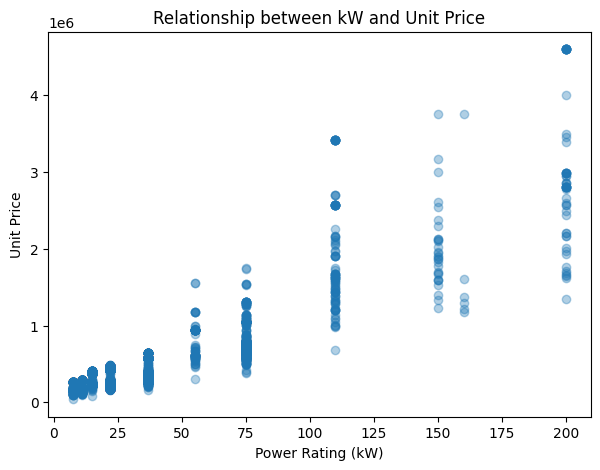

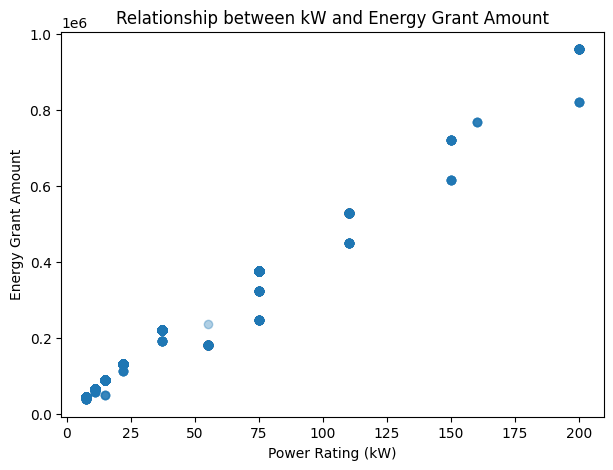

In [25]:
# Scatter: Kw vs Unit Price
plot_df = df.dropna(subset=['Kw', 'Unit Price'])
plt.figure(figsize=(7,5))
plt.scatter(plot_df['Kw'], plot_df['Unit Price'], alpha=0.35)
plt.xlabel('Power Rating (kW)')
plt.ylabel('Unit Price')
plt.title('Relationship between kW and Unit Price')
plt.show()

# Scatter: Kw vs Energy Grant Amount
plot_df = df.dropna(subset=['Kw', 'Energy grant amount'])
plt.figure(figsize=(7,5))
plt.scatter(plot_df['Kw'], plot_df['Energy grant amount'], alpha=0.35)
plt.xlabel('Power Rating (kW)')
plt.ylabel('Energy Grant Amount')
plt.title('Relationship between kW and Energy Grant Amount')
plt.show()

## 7. Add attributes from Gross Margin Rate formula

Gross Margin Rate formula:

\[
	ext{GMR} =
rac{	ext{Sales Revenue} - 	ext{COGS}}{	ext{Sales Revenue}}
\]

Kalau `Subtotal Price` dianggap sebagai Sales Revenue, maka bisa dibuat atribut turunan:

\[
	ext{Gross Profit Amount} = 	ext{Revenue} 	imes 	ext{GMR}
\]

\[
	ext{Estimated COGS} = 	ext{Revenue} 	imes (1 - 	ext{GMR})
\]

Ini bukan data cost asli, tapi **estimated cost based on the margin formula**.

In [26]:
# Rename columns to snake_case
df = df.rename(columns={
    'Quote ID': 'quote_id',
    'Product': 'product',
    'Kw': 'kw',
    'Unit Price': 'unit_price',
    'Qty': 'qty',
    'Subtotal Price': 'subtotal_price',
    'Gross Margin Rate ': 'gross_margin_rate',
    'Convert to Order (0:Success, 1:Fail)': 'convert_to_order',
    'Energy grant amount': 'energy_grant_amount',
    'Competitor A': 'competitor_a',
    'Competitor B': 'competitor_b',
    'Competitor C': 'competitor_c',
    'subtotal_expected': 'subtotal_expected',
    'subtotal_diff': 'subtotal_diff',
    'subtotal_diff_abs': 'subtotal_diff_abs'
})

# Optional: cek hasil nama kolom
print(df.columns)

Index(['quote_id', 'product', 'kw', 'unit_price', 'qty', 'subtotal_price',
       'gross_margin_rate', 'convert_to_order', 'energy_grant_amount',
       'competitor_a', 'competitor_b', 'competitor_c', 'subtotal_expected',
       'subtotal_diff', 'subtotal_diff_abs'],
      dtype='object')


In [27]:
df['is_success'] = (df['convert_to_order'] == 0).astype(int)  # helper only; original label still unchanged

df['gross_profit_amount'] = df['subtotal_price'] * df['gross_margin_rate']
df['estimated_cogs'] = df['subtotal_price'] * (1 - df['gross_margin_rate'])
df['unit_gross_profit'] = df['unit_price'] * df['gross_margin_rate']
df['unit_estimated_cogs'] = df['unit_price'] * (1 - df['gross_margin_rate'])

# grant features
# customer-effective quoted cost after grant, assuming grant reduces customer effective cost
# Use max denominator guard for ratio calculations
EPS = 1e-9
df['effective_subtotal_after_grant'] = df['subtotal_price'] - df['energy_grant_amount'].fillna(0)
df['grant_to_subtotal_ratio'] = df['energy_grant_amount'] / (df['subtotal_price'] + EPS)
df['grant_to_unit_price_ratio'] = df['energy_grant_amount'] / (df['unit_price'] + EPS)

df[[
    'quote_id','subtotal_price','gross_margin_rate','gross_profit_amount',
    'estimated_cogs','energy_grant_amount','effective_subtotal_after_grant'
]].head()

,quote_id,subtotal_price,gross_margin_rate,gross_profit_amount,estimated_cogs,energy_grant_amount,effective_subtotal_after_grant
0,Q-00114,136000.0,0.0712,9.683200e+03,1.263168e+05,66000,70000.0
1,Q-00119,580000.0,0.3079,1.785820e+05,4.014180e+05,222000,358000.0
2,Q-00161,2379000.0,0.4224,1.004890e+06,1.374110e+06,720000,1659000.0
3,Q-00214,300000.0,0.6787,2.036100e+05,9.639000e+04,132000,168000.0
4,Q-00517,228964.0,0.2949,6.752148e+04,1.614425e+05,132000,96964.0


## 8. Rate GMR terhadap success rate

Karena `0 = Success`, success rate dihitung sebagai proporsi row dengan `convert_to_order == 0`.

Di sini kita binning GMR untuk melihat margin range mana yang cenderung lebih sering convert.

In [28]:
# Create GMR bins by quantile, safer if distribution is skewed
# duplicates='drop' handles repeated values
valid_gmr = df.dropna(subset=['gross_margin_rate']).copy()
valid_gmr['gmr_bin'] = pd.qcut(valid_gmr['gross_margin_rate'], q=10, duplicates='drop')

gmr_success = valid_gmr.groupby('gmr_bin', observed=True).agg(
    n=('quote_id','count'),
    gmr_min=('gross_margin_rate','min'),
    gmr_max=('gross_margin_rate','max'),
    gmr_mean=('gross_margin_rate','mean'),
    success_rate=('is_success','mean'),
    avg_unit_price=('unit_price','mean'),
    avg_grant=('energy_grant_amount','mean')
).reset_index()

gmr_success

,gmr_bin,n,gmr_min,gmr_max,gmr_mean,success_rate,avg_unit_price,avg_grant
0,"(-1.3239999999999998, 0.118]",513,-1.3226,0.1182,0.060551,0.528265,229039.013177,107082.690058
1,"(0.118, 0.205]",487,0.1187,0.2049,0.170821,0.310062,261170.774661,113358.809035
2,"(0.205, 0.291]",499,0.2051,0.2912,0.248874,0.547094,390109.827054,193968.256513
3,"(0.291, 0.352]",501,0.2915,0.3518,0.322925,0.391218,488039.101657,238137.724551
4,"(0.352, 0.398]",497,0.3538,0.3979,0.380448,0.213280,420627.515412,197228.410463
5,"(0.398, 0.426]",499,0.3980,0.4257,0.408503,0.122244,369666.363888,174027.294589
6,"(0.426, 0.452]",501,0.4259,0.4525,0.439329,0.117764,372056.768663,189904.031936
7,"(0.452, 0.498]",501,0.4531,0.4983,0.474749,0.165669,423470.112176,197942.914172
8,"(0.498, 0.619]",535,0.4991,0.6191,0.586848,0.095327,657978.080991,195558.467290
9,"(0.619, 0.921]",461,0.6193,0.9211,0.658148,0.034707,718636.610846,222887.635575


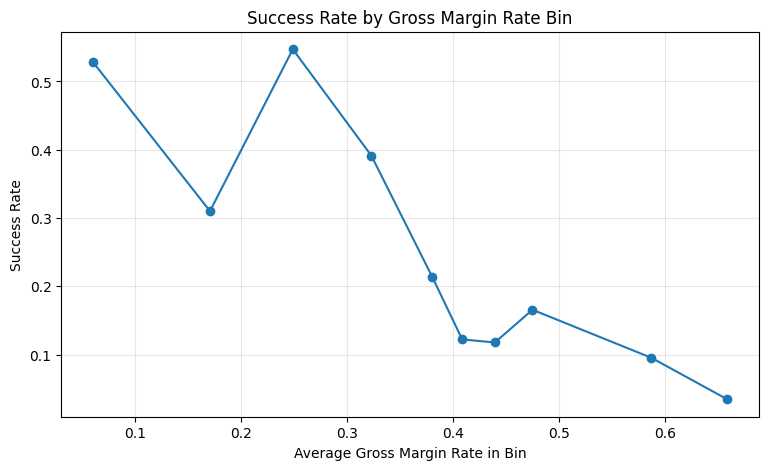

In [29]:
plt.figure(figsize=(9,5))
plt.plot(gmr_success['gmr_mean'], gmr_success['success_rate'], marker='o')
plt.xlabel('Average Gross Margin Rate in Bin')
plt.ylabel('Success Rate')
plt.title('Success Rate by Gross Margin Rate Bin')
plt.grid(True, alpha=0.3)
plt.show()

# End